# Sentiment Analysis on Amazon Product Reviews

## Project Overview

This project analyzes customer reviews from Amazon products and classifies them into Positive, Negative, and Neutral sentiments using Natural Language Processing (NLP).

## Objectives

- Analyze customer opinions from review text.
- Classify reviews into sentiment categories.
- Visualize sentiment distribution.
- Generate word clouds to identify common words.
- Extract actionable insights from customer feedback.

## Tools & Libraries Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- TextBlob
- WordCloud

In [10]:
df = pd.read_csv("../data/1429_1.csv")
df.head()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_924\1752437085.py:1: DtypeWarning: Columns (0: name, 1: reviews.didPurchase) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/1429_1.csv")


,id,name,asins,brand,categories,keys,manufacturer,reviews.date,reviews.dateAdded,reviews.dateSeen,...,reviews.doRecommend,reviews.id,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.userCity,reviews.userProvince,reviews.username
0,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,This product so far has not disappointed. My c...,Kindle,NaN,NaN,Adapter
1,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,great for beginner or experienced person. Boug...,very fast,NaN,NaN,truman
2,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,Inexpensive tablet for him to use and learn on...,Beginner tablet for our 9 year old son.,NaN,NaN,DaveZ
3,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,4.0,http://reviews.bestbuy.com/3545/5620406/review...,I've had my Fire HD 8 two weeks now and I love...,Good!!!,NaN,NaN,Shacks
4,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-12T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,I bought this for my grand daughter when she c...,Fantastic Tablet for kids,NaN,NaN,explore42


In [6]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from textblob import TextBlob
from wordcloud import WordCloud

import warnings
warnings.filterwarnings("ignore")

# Loading the Dataset

The dataset contains Amazon customer reviews and product-related information. The first step is to load the dataset and inspect its contents.

In [2]:
import os
print(os.getcwd())
print(os.listdir())

c:\Users\LENOVO\OneDrive\文档\Projects\CodeAlpha_SentimenAnalysis
['data', 'images', 'README.md', 'Sentiment_Analysis.ipynb']


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from textblob import TextBlob
from wordcloud import WordCloud

import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("data/1429_1.csv")
df.head()

,id,name,asins,brand,categories,keys,manufacturer,reviews.date,reviews.dateAdded,reviews.dateSeen,...,reviews.doRecommend,reviews.id,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.userCity,reviews.userProvince,reviews.username
0,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,This product so far has not disappointed. My c...,Kindle,NaN,NaN,Adapter
1,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,great for beginner or experienced person. Boug...,very fast,NaN,NaN,truman
2,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,Inexpensive tablet for him to use and learn on...,Beginner tablet for our 9 year old son.,NaN,NaN,DaveZ
3,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,4.0,http://reviews.bestbuy.com/3545/5620406/review...,I've had my Fire HD 8 two weeks now and I love...,Good!!!,NaN,NaN,Shacks
4,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-12T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,I bought this for my grand daughter when she c...,Fantastic Tablet for kids,NaN,NaN,explore42


In [4]:
df.columns

Index(['id', 'name', 'asins', 'brand', 'categories', 'keys', 'manufacturer',
       'reviews.date', 'reviews.dateAdded', 'reviews.dateSeen',
       'reviews.didPurchase', 'reviews.doRecommend', 'reviews.id',
       'reviews.numHelpful', 'reviews.rating', 'reviews.sourceURLs',
       'reviews.text', 'reviews.title', 'reviews.userCity',
       'reviews.userProvince', 'reviews.username'],
      dtype='str')

# Review Text Selection

For sentiment analysis, we will use the `reviews.text` column, which contains customer review comments.

In [5]:
reviews_df = df[['reviews.text']]

reviews_df.head()

,reviews.text
0,This product so far has not disappointed. My c...
1,great for beginner or experienced person. Boug...
2,Inexpensive tablet for him to use and learn on...
3,I've had my Fire HD 8 two weeks now and I love...
4,I bought this for my grand daughter when she c...


In [6]:
reviews_df.shape

(34660, 1)

In [7]:
reviews_df.isnull().sum()

reviews.text    1
dtype: int64

# Data Cleaning

Before performing sentiment analysis, missing values must be removed and the review text converted into string format.

In [8]:
reviews_df = reviews_df.dropna()

reviews_df['reviews.text'] = reviews_df['reviews.text'].astype(str)

reviews_df.shape

(34659, 1)

In [9]:
reviews_df.head()

,reviews.text
0,This product so far has not disappointed. My c...
1,great for beginner or experienced person. Boug...
2,Inexpensive tablet for him to use and learn on...
3,I've had my Fire HD 8 two weeks now and I love...
4,I bought this for my grand daughter when she c...


## Data Cleaning Observations

- Missing review records were removed.
- Review text was converted to string format.
- The dataset is now ready for sentiment analysis.

# Sentiment Analysis

TextBlob is used to calculate sentiment polarity for each review.

Polarity Range:
- Positive : Greater than 0
- Neutral : Equal to 0
- Negative : Less than 0

In [10]:
def get_sentiment(text):
    polarity = TextBlob(text).sentiment.polarity

    if polarity > 0:
        return "Positive"
    elif polarity < 0:
        return "Negative"
    else:
        return "Neutral"

In [11]:
reviews_df['Sentiment'] = reviews_df['reviews.text'].apply(get_sentiment)

reviews_df.head()

,reviews.text,Sentiment
0,This product so far has not disappointed. My c...,Positive
1,great for beginner or experienced person. Boug...,Positive
2,Inexpensive tablet for him to use and learn on...,Positive
3,I've had my Fire HD 8 two weeks now and I love...,Positive
4,I bought this for my grand daughter when she c...,Positive


In [12]:
reviews_df['Sentiment'].value_counts()

Sentiment
Positive    31162
Neutral      2000
Negative     1497
Name: count, dtype: int64

## Sentiment Classification Results

Each review has been classified into one of three categories:

- Positive
- Negative
- Neutral

The distribution of sentiments will be visualized in the next section.

In [13]:
reviews_df['Sentiment'].value_counts()

Sentiment
Positive    31162
Neutral      2000
Negative     1497
Name: count, dtype: int64

## Sentiment Analysis Observation

The majority of customer reviews are positive, indicating high customer satisfaction with the products.

A smaller number of reviews are neutral, while only a limited portion of reviews express negative sentiment.

This suggests that most customers had a favorable experience with the products reviewed.

# Sentiment Distribution Visualization

Visualizing sentiment distribution helps understand the overall customer opinion toward the products.

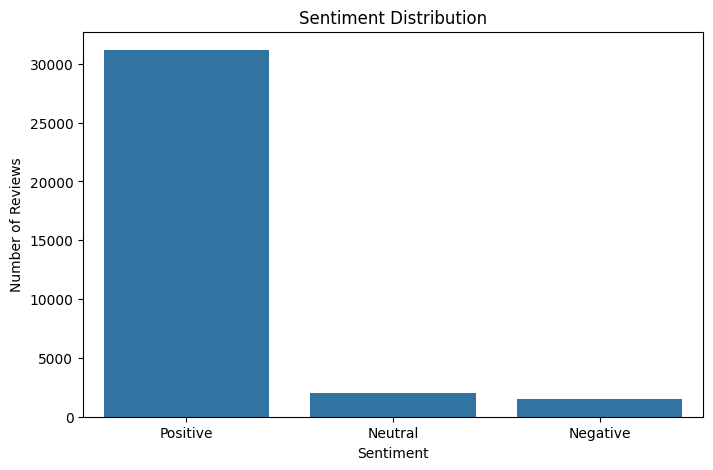

In [14]:
sentiment_counts = reviews_df['Sentiment'].value_counts()

plt.figure(figsize=(8,5))
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.savefig("images/sentiment_distribution.png")

plt.show()

## Bar Chart Observation

The positive sentiment category dominates the dataset, significantly exceeding neutral and negative reviews.

Negative reviews represent only a small fraction of the total customer feedback.

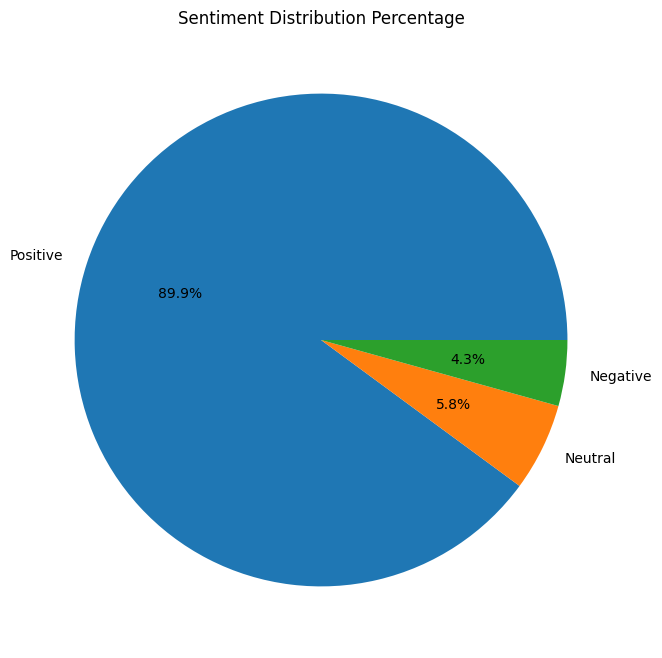

In [15]:
plt.figure(figsize=(8,8))

reviews_df['Sentiment'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Sentiment Distribution Percentage")
plt.ylabel("")

plt.savefig("images/sentiment_pie_chart.png")

plt.show()

## Pie Chart Observation

The pie chart confirms that positive reviews account for the vast majority of customer feedback.

Neutral and negative sentiments together represent only a small percentage of total reviews.

# Positive Reviews Word Cloud

The word cloud highlights frequently occurring words in positive customer reviews.

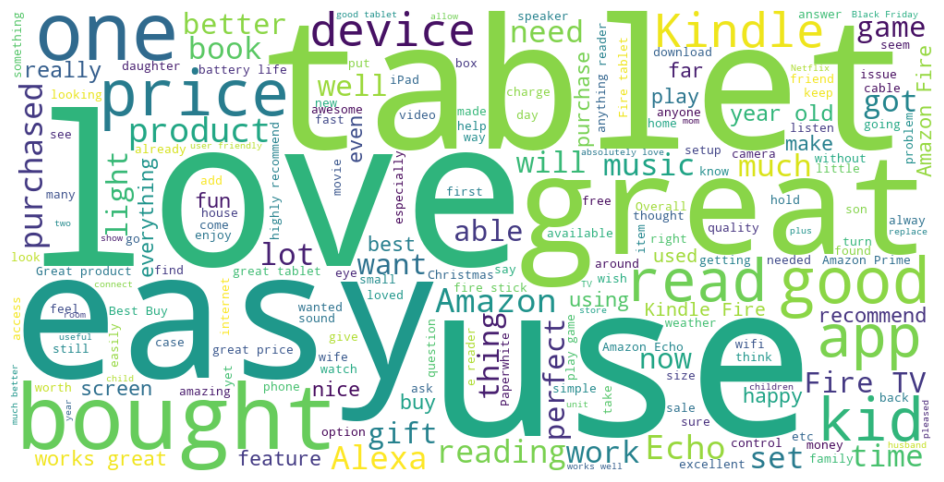

In [16]:
positive_reviews = " ".join(
    reviews_df[reviews_df['Sentiment'] == 'Positive']['reviews.text']
)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(positive_reviews)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')

plt.savefig("images/positive_wordcloud.png")

plt.show()

# Negative Reviews Word Cloud

The word cloud highlights frequently occurring words in negative customer reviews.

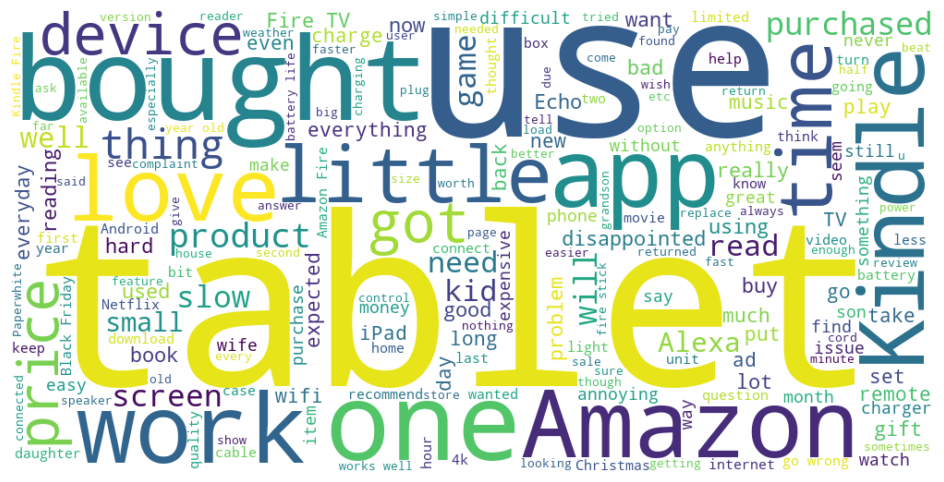

In [17]:
negative_reviews = " ".join(
    reviews_df[reviews_df['Sentiment'] == 'Negative']['reviews.text']
)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(negative_reviews)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')

plt.savefig("images/negative_wordcloud.png")

plt.show()

# Key Insights

1. Positive reviews dominate the dataset, indicating strong customer satisfaction.

2. A relatively small number of reviews express negative sentiment.

3. Customer feedback is generally favorable toward the products.

4. Word cloud analysis helps identify commonly used terms in both positive and negative reviews.

5. Sentiment analysis provides valuable insights for understanding customer perception and product performance.

# Conclusion

This project successfully applied Natural Language Processing (NLP) techniques to analyze customer reviews from Amazon products.

Using TextBlob sentiment analysis, reviews were classified into Positive, Neutral, and Negative categories. The results showed that the majority of customer feedback was positive, reflecting strong customer satisfaction.

Visualizations and word clouds provided additional insights into customer opinions and highlighted frequently used terms across sentiments.

The findings demonstrate how sentiment analysis can be used to understand customer behavior, evaluate product performance, and support data-driven decision-making.

In [18]:
sentiment_summary = reviews_df['Sentiment'].value_counts()

print(sentiment_summary)

Sentiment
Positive    31162
Neutral      2000
Negative     1497
Name: count, dtype: int64
